# Типы локальных экономик: кластеризация муниципальных образований по тратам

**Задача.** Найти группы муниципальных образований (МО) с похожей экономикой и проследить, как эти группы меняются во времени. На этом шаге используем только данные СберИндекса о тратах по 5 категориям. Остальные признаки добавятся позже: для этого достаточно дописать столбцы в таблицу атрибутов (раздел 2) или новую меру близости (раздел 3).

**Как читать ноутбук.** Каждый раздел начинается с короткого объяснения: что делаем, зачем и как это трактовать экономически. Все настройки собраны в одной ячейке конфигурации. Код разбит на небольшие функции, каждая делает одну вещь.

| Раздел | Что внутри | Критерий оценки |
|---|---|---|
| 0 | Методология простым языком, словарь метрик | 1, 4 |
| 1 | Данные и первичный анализ | 5 |
| 2 | Пространство признаков (атрибуты узлов) | задание п.1 |
| 3 | Меры близости между МО | 2 |
| 4 | Правило построения рёбер и его влияние на сеть | 2, задание пп.2–3 |
| 5 | Методы кластеризации | 3 |
| 6 | Оценка качества (ICVI) и выбор числа кластеров | 3, 4 |
| 7 | Динамика кластеров во времени | задание п.4 |
| 8 | Интерпретация типов экономик | 5 |
| 9 | Итоги и ограничения | 5 |

## 0. Методология простым языком

Каждое МО описывается помесячными тратами жителей по 5 категориям: здоровье, общественное питание, продовольствие, маркетплейсы, транспорт. Получается многомерный временной ряд: таблица «месяц × категория» для каждого МО.

Пайплайн из семи шагов:

1. **Подготовка данных.** Оставляем МО с полной историей, логарифмируем суммы. Логарифм нужен, потому что траты различаются в разы, а нас интересуют относительные различия («на 20% больше»), а не абсолютные рубли.
2. **Признаки (атрибуты узлов).** Считаем три взгляда на одно МО:
   *уровень* (сколько тратят), *структура* (на что тратят), *собственная динамика* (как траты меняются относительно страны в целом).
3. **Близость между МО.** Для каждой пары МО считаем расстояние пятью способами: евклидово, корреляционное, косинусное, лаговое (кто кого опережает) и DTW (похожая форма с допустимым сдвигом во времени).
4. **Сеть.** Соединяем ребром МО, которые входят в списки ближайших соседей друг друга (взаимные k ближайших соседей). Вес ребра тем больше, чем ближе МО.
5. **Кластеризация.** Разбиваем МО на группы несколькими методами: k-medoids, иерархическая, спектральная, Louvain, HDBSCAN, TimeSeriesKMeans.
6. **Выбор числа кластеров.** Перебираем k от 2 до 15. Для каждого k считаем шесть индексов качества и выбираем k, на котором индексы в сумме лучше всего согласуются. Дополнительно проверяем устойчивость разбиения к подвыборке МО.
7. **Динамика.** Повторяем шаги 3–5 в скользящем окне по месяцам, сопоставляем кластеры соседних окон и фиксируем события: кластер сохранился, вырос, распался, слился с другим.

Итог: у каждого МО есть тип экономики на каждый момент времени, а у каждого типа есть понятный профиль трат.

### Словарь метрик и сокращений

**Индексы качества кластеризации (ICVI, internal cluster validity indices).** Такие индексы оценивают разбиение без «правильного ответа», только по самим данным. Хорошее разбиение: внутри кластера объекты похожи друг на друга, между кластерами различаются.

| Индекс | Простыми словами | Лучше, когда |
|---|---|---|
| **SW**, Silhouette Width (силуэт) | Для каждого МО сравниваем среднее расстояние до «своих» ($a$) и до ближайшего чужого кластера ($b$): $s=\frac{b-a}{\max(a,b)}$. Затем усредняем. Значение 1 означает, что МО явно на своём месте, 0 — что МО на границе, отрицательное — что МО скорее относится к соседнему кластеру. | больше (от −1 до 1) |
| **CH**, индекс Калинского–Харабаша | Отношение разброса *между* центрами кластеров к разбросу *внутри* кластеров с поправкой на число кластеров. Похож на F-статистику дисперсионного анализа. | больше |
| **S_Dbw**, Scatter + Density between (Halkidi, Vazirgiannis, 2001) | Сумма двух слагаемых. *Scat* показывает, насколько «рыхлые» кластеры по сравнению со всей выборкой. *Dens_bw* показывает, много ли точек лежит посередине между центрами двух кластеров. Если много, кластеры сливаются друг с другом. | меньше |
| **AVI** | В методичке расшифровки нет, общепринятого определения мы тоже не нашли. **Рабочая трактовка:** однородность *атрибутов* внутри кластеров. Это среднее расстояние между атрибутами МО одного кластера, делённое на среднее расстояние по всем парам МО. Значение 0.6 означает, что МО внутри кластера на 40% ближе друг к другу, чем случайная пара. | меньше |
| **AVU** | То же для пар МО *из разных кластеров*. Показывает, насколько кластеры различаются по атрибутам. | больше (выше 1) |
| **MQ**, Modularity Quality | Модулярность Ньюмена $Q=\sum_c\left[\frac{L_c}{m}-\left(\frac{d_c}{2m}\right)^2\right]$. Сравнивает вес рёбер внутри кластеров ($L_c$) с тем, что получилось бы в случайной сети с теми же степенями узлов ($m$ — общий вес рёбер, $d_c$ — сумма степеней кластера). Показывает, насколько кластеры являются «сообществами» в построенной сети. | больше (обычно 0.3–0.7 — хорошо) |

AVI и AVU измеряются в общем пространстве атрибутов, одинаковом для всех методов, поэтому по ним честно сравнивать разные меры близости. SW, CH и S_Dbw считаются в геометрии «своей» меры (подробнее в разделе 6). **Если организаторы дадут свои формулы AVI и AVU, достаточно заменить одну функцию `attribute_indices`.** В разработке ПО встречается другая трактовка MQ — Modularization Quality (Mancoridis и др., 1998). Она тоже основана на отношении внутренних и внешних рёбер, поэтому выводы по ней обычно совпадают с модулярностью.

**Прочие сокращения**

| Термин | Смысл |
|---|---|
| **ARI**, Adjusted Rand Index | Совпадение двух разбиений одних и тех же объектов. 1 означает полное совпадение, 0 — совпадение на уровне случайного. Используем для устойчивости и для сравнения методов. |
| **Жаккар** | $J(A,B)=\frac{|A\cap B|}{|A\cup B|}$ — доля общих МО у двух кластеров. Используется для сопоставления кластеров соседних месяцев. |
| **DTW**, Dynamic Time Warping | Расстояние между рядами, которое разрешает «растягивать» время. Два МО с одинаковым пиком трат, сдвинутым на месяц, окажутся близки. |
| **Сакое–Чиба** | Ограничение DTW: сдвиг не больше `DTW_RADIUS` месяцев. Защищает от бессмысленных сопоставлений (январь с июлем). |
| **kNN / mutual kNN** | k ближайших соседей. «Взаимные» означает, что ребро ставится, только если каждый из двух МО входит в k ближайших у другого. |
| **Louvain** | Алгоритм поиска сообществ в сети, максимизирующий модулярность. Число кластеров подбирает сам, параметр `resolution` регулирует их размер. |
| **HDBSCAN** | Кластеризация по плотности. Сам находит число кластеров и помечает нетипичные МО как «шум» (метка −1). |
| **MDS** | Многомерное шкалирование: по матрице расстояний строит координаты точек, чтобы посчитать CH и S_Dbw, которым нужны координаты. |
| **Борда** | Способ объединить несколько рейтингов. Каждое k получает место по каждому индексу, места складываются, побеждает наименьшая сумма. |

In [3]:
import warnings
warnings.filterwarnings('ignore')

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from scipy.linalg import eigh
from scipy.optimize import linear_sum_assignment
from scipy.sparse.csgraph import connected_components
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.tree import DecisionTreeClassifier, export_text
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)

### Конфигурация
Все параметры исследования собраны здесь. Чтобы воспроизвести результат, достаточно запустить ноутбук целиком с теми же значениями.

In [4]:
SEED = 42
DATA_PATH = 'data/potrebitelskie-beznalicnye-rashody-na-urovne-munizipalnyh-obrazovanij_ru_1764079373653.parquet'          # длинная таблица: period, value, category_15, mo, ...
CATEGORIES = ['Здоровье', 'Общественное питание', 'Продовольствие', 'Маркетплейсы', 'Транспорт']

K_RANGE = range(2, 16)           # перебираемое число кластеров
K_NN = 15                        # число соседей при построении сети
MAX_LAG = 2                      # максимальный лаг (мес.) для лаговой корреляции
DTW_RADIUS = 2                   # окно Сакое–Чиба для DTW (мес.)
LOUVAIN_RES = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
HDBSCAN_MIN_SIZE = 20            # минимальный размер кластера для HDBSCAN
RUN_SLOW_TSKMEANS = True         # DBA- и soft-DTW k-means работают долго

# Разбиения с кластером больше 80% МО или меньше 1% МО считаем вырожденными
MAX_CLUSTER_SHARE = 0.80
MIN_CLUSTER_SHARE = 0.01
N_BOOT = 10                      # число подвыборок при проверке устойчивости

WINDOW = 6                       # длина окна (мес.) для динамики
STEP = 1                         # шаг окна (мес.)
ALPHA = 0.3                      # сглаживание во времени (0 = без сглаживания)

OUT_DIR = Path('results')
OUT_DIR.mkdir(exist_ok=True)
np.random.seed(SEED)

import sklearn, tslearn
print('numpy', np.__version__, '| pandas', pd.__version__, '| sklearn', sklearn.__version__,
      '| tslearn', tslearn.__version__, '| networkx', nx.__version__)

numpy 2.5.3 | pandas 3.0.5 | sklearn 1.9.1 | tslearn 0.9.0 | networkx 3.7


## 1. Данные

Сводим длинную таблицу в тензор `X_raw[МО, месяц, категория]`. Оставляем только МО, у которых есть все месяцы и все 5 категорий: для сравнения рядов нужна одинаковая длина, а заполнение пропусков у небольшого числа МО добавило бы искусственный сигнал.

In [9]:
costs = pd.read_parquet(DATA_PATH)   # или pd.read_parquet / уже загруженный costs
costs['period'] = pd.to_datetime(costs['period'])

costs_filtered = costs[costs['category_15'].isin(CATEGORIES)]
pivot_costs = (costs_filtered
               .pivot_table(index=['mo', 'period'], columns='category_15', values='value', aggfunc='mean')
               .reindex(columns=CATEGORIES)
               .sort_index())

# 1) только МО с полным числом месяцев
period_counts = pivot_costs.groupby(level='mo').size()
full_mo = period_counts[period_counts == period_counts.max()].index
# 2) только МО без пропусков по категориям
has_nan = pivot_costs.isna().any(axis=1).groupby(level='mo').any()
good_mo = [mo for mo in full_mo if not has_nan[mo]]
pivot_costs = pivot_costs.loc[good_mo]

mo_names = pivot_costs.index.get_level_values('mo').unique().to_numpy()
periods = pivot_costs.index.get_level_values('period').unique().sort_values()
n_mo, n_periods, n_cat = len(mo_names), len(periods), len(CATEGORIES)
assert len(pivot_costs) == n_mo * n_periods, 'у МО разные наборы месяцев'

X_raw = np.clip(pivot_costs.values.reshape(n_mo, n_periods, n_cat), 0, None)

print(f'Всего МО в данных: {len(period_counts)}')
print(f'Отброшено из-за неполной истории: {len(period_counts) - len(full_mo)}, из-за пропуска категории: {len(full_mo) - n_mo}')
print(f'В анализе: {n_mo} МО × {n_periods} мес. ({periods.min():%Y-%m} … {periods.max():%Y-%m}) × {n_cat} категорий')

Всего МО в данных: 2118
Отброшено из-за неполной истории: 166, из-за пропуска категории: 0
В анализе: 1952 МО × 24 мес. (2023-01 … 2024-12) × 5 категорий


### Первичный анализ
Смотрим на масштаб трат, долю нулей и общую для страны помесячную динамику. Суммы порядка десятков тысяч рублей в месяц для целого района слишком малы для совокупных трат, так что это, скорее всего, **средние траты в расчёте на человека или клиента**. Это стоит проверить в описании набора СберИндекса. Если так, дополнительная нормировка на численность населения не нужна, и МО разного размера сравнимы напрямую.

In [10]:
mean_by_mo = pd.DataFrame(X_raw.mean(axis=1), columns=CATEGORIES, index=mo_names)
eda = mean_by_mo.describe(percentiles=[.05, .25, .5, .75, .95]).T
eda['доля нулей'] = (X_raw == 0).mean(axis=(0, 1))
eda['max/median'] = eda['max'] / eda['50%']
print('Средние месячные траты по МО, руб.:')
display(eda.round(1))

national = pd.DataFrame(X_raw.mean(axis=0), index=periods.strftime('%Y-%m'), columns=CATEGORIES)
print('Средние траты по всем МО помесячно (общий для страны сигнал: сезонность и тренд):')
display((national / national.mean()).round(2).T)

Средние месячные траты по МО, руб.:


,count,mean,std,min,5%,25%,50%,75%,95%,max,доля нулей,max/median
Здоровье,1952.000,1411.900,634.500,451.300,829.100,1009.900,1174.800,1578.500,2784.100,4742.800,0.000,4.000
Общественное питание,1952.000,1169.400,1211.700,68.200,190.200,350.800,622.800,1526.000,3838.700,7481.700,0.000,12.000
Продовольствие,1952.000,12029.000,2718.500,5476.400,8522.700,10145.600,11561.000,13706.100,16338.700,27243.700,0.000,2.400
Маркетплейсы,1952.000,3904.400,1250.400,952.600,2140.900,3003.500,3743.200,4625.000,6226.000,8327.100,0.000,2.200
Транспорт,1952.000,1719.900,871.200,524.800,832.700,1102.500,1391.300,2076.400,3565.000,5042.600,0.000,3.600


Средние траты по всем МО помесячно (общий для страны сигнал: сезонность и тренд):


period,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
Здоровье,0.930,0.990,1.060,0.920,0.890,0.860,0.860,0.930,0.930,0.980,0.990,1.060,0.980,1.060,1.110,1.080,1.000,0.950,0.990,1.000,1.050,1.140,1.100,1.130
Общественное питание,0.810,0.800,0.890,0.820,0.870,0.940,1.050,1.070,0.960,0.910,0.880,0.910,0.880,0.910,1.040,1.020,1.080,1.190,1.280,1.290,1.130,1.120,1.050,1.090
Продовольствие,0.840,0.880,0.950,0.920,0.950,0.970,0.990,0.970,0.920,0.930,0.930,1.160,0.900,0.970,1.070,1.050,1.090,1.100,1.110,1.050,0.980,1.020,1.010,1.230
Маркетплейсы,0.550,0.620,0.700,0.640,0.670,0.680,0.730,0.780,0.800,0.920,1.120,1.250,0.860,1.020,1.130,1.100,1.090,1.110,1.160,1.250,1.210,1.360,1.480,1.760
Транспорт,0.890,0.890,0.920,0.880,0.910,0.950,1.030,1.060,0.980,0.980,0.940,1.000,0.910,0.910,0.970,1.000,1.020,1.080,1.170,1.170,1.080,1.100,1.050,1.120


## 2. Пространство признаков

Смотрим на экономику МО с трёх сторон. Каждая сторона даёт своё представление данных.

| Представление | Формула | Экономический смысл | Где используется |
|---|---|---|---|
| **A. Уровни** `X_level` | $\frac{\log(1+x_{t,c}) - \mu_c}{\sigma_c}$, где $\mu_c, \sigma_c$ считаются по всей выборке для категории $c$ | Сколько тратят жители: доходы, цены, развитость инфраструктуры потребления | евклидово расстояние, DTW, TimeSeriesKMeans |
| **B. Структура** | средние траты по категориям за период, вектор из 5 чисел | На что тратят: «корзина» локальной экономики (доступность общепита, роль маркетплейсов при слабой рознице и т. д.) | косинусное сходство |
| **C. Собственная динамика** `X_dev` | $\log(1+x_{i,t,c}) - \overline{\log(1+x_{\cdot,t,c})}$ | Как МО отклоняется от общероссийского движения. Вычитание среднего по стране за месяц убирает общую сезонность (декабрьский пик) и инфляцию. Без этого у всех МО корреляция была бы около 1. | корреляции, лаговые корреляции |

Отдельно считаем **таблицу атрибутов узлов** `F`: понятные числа, по которым мы будем описывать и сравнивать кластеры.

* уровень трат (лог суммы по 5 категориям);
* доля каждой категории в сумме — структура потребления;
* годовой темп роста по каждой категории — наклон лог-ряда × 12;
* волатильность по каждой категории — стандартное отклонение помесячных лог-приростов;
* сезонность — отношение максимального месяца к минимальному.

Новые признаки (население, бюджет, тип МО, координаты) позже добавляются как новые столбцы `F`.

In [11]:
X_log = np.log1p(X_raw)

# A. Уровни: логарифм + стандартизация по каждой категории на всей выборке
X_level = (X_log - X_log.mean(axis=(0, 1))) / X_log.std(axis=(0, 1))

# C. Собственная динамика: отклонение от среднего по всем МО в этот месяц
X_dev = X_log - X_log.mean(axis=0, keepdims=True)


def make_attributes(X):
    # Таблица понятных атрибутов МО по массиву трат X[МО, месяц, категория]
    X_log = np.log1p(X)
    total = X.sum(axis=2)
    shares = X / np.where(total == 0, 1, total)[:, :, None]
    t = np.arange(X.shape[1])

    F = {'Уровень: всего (лог)': np.log1p(total).mean(axis=1)}
    for c, name in enumerate(CATEGORIES):
        F[f'Доля: {name}'] = shares[:, :, c].mean(axis=1)
    for c, name in enumerate(CATEGORIES):
        F[f'Рост/год: {name}'] = np.polyfit(t, X_log[:, :, c].T, 1)[0] * 12
    for c, name in enumerate(CATEGORIES):
        F[f'Волатильность: {name}'] = np.diff(X_log[:, :, c], axis=1).std(axis=1)
    F['Сезонность: max/min'] = total.max(axis=1) / np.where(total.min(axis=1) == 0, 1, total.min(axis=1))
    return pd.DataFrame(F, index=mo_names)


F = make_attributes(X_raw)
F_std = (F - F.mean()) / F.std()
D_ATTR = squareform(pdist(F_std.values))       # расстояния в пространстве атрибутов (для AVI/AVU)
display(F.describe().T[['mean', 'std', 'min', '50%', 'max']])

,mean,std,min,50%,max
Уровень: всего (лог),9.871,0.265,9.257,9.813,10.582
Доля: Здоровье,0.069,0.013,0.030,0.067,0.120
Доля: Общественное питание,0.049,0.036,0.005,0.036,0.189
Доля: Продовольствие,0.609,0.066,0.360,0.620,0.818
Доля: Маркетплейсы,0.191,0.039,0.036,0.190,0.357
Доля: Транспорт,0.082,0.022,0.030,0.078,0.173
Рост/год: Здоровье,0.078,0.072,-0.568,0.082,0.400
Рост/год: Общественное питание,0.147,0.156,-1.081,0.171,1.053
Рост/год: Продовольствие,0.107,0.038,-0.059,0.113,0.301
Рост/год: Маркетплейсы,0.522,0.130,0.269,0.497,1.595


In [12]:
# Сильно коррелирующие атрибуты дублируют друг друга и «перевешивают» в расстояниях.
corr_attr = F.corr(method='spearman')
pairs = (corr_attr.where(np.triu(np.ones(corr_attr.shape, dtype=bool), k=1))
         .stack().rename('rho').reset_index())
print('Пары атрибутов с |rho| > 0.7:')
display(pairs[pairs['rho'].abs() > 0.7].sort_values('rho', key=abs, ascending=False))

Пары атрибутов с |rho| > 0.7:


,level_0,level_1,rho
46,Доля: Общественное питание,Волатильность: Общественное питание,-0.848
219,Волатильность: Общественное питание,Волатильность: Транспорт,0.804
152,Рост/год: Продовольствие,Сезонность: max/min,0.796
199,Волатильность: Здоровье,Волатильность: Общественное питание,0.794
202,Волатильность: Здоровье,Волатильность: Транспорт,0.755
2,Уровень: всего (лог),Доля: Общественное питание,0.725
112,Рост/год: Здоровье,Рост/год: Транспорт,0.723


## 3. Меры близости между МО

Каждая мера отвечает на свой вопрос «чем похожи два МО». Везде $i, j$ — МО, $t$ — месяц, $c$ — категория, $T$ — число месяцев, $C=5$.

| Мера | Формула расстояния | Когда МО близки | Ограничения |
|---|---|---|---|
| **euclid** (на A) | $d_{ij}=\sqrt{\sum_{t,c}(a_{itc}-a_{jtc})^2}$ | Одинаковые уровни трат в каждом месяце | Не прощает сдвиги во времени, в основном отражает уровень |
| **corr** (на C) | $d_{ij}=1-\frac1C\sum_c \rho\big(x_{ic}, x_{jc}\big)$ | МО синхронно отклоняются от страны: вместе растут и падают | Не видит уровень. На коротких рядах корреляция шумная. |
| **cosine** (на B) | $d_{ij}=1-\frac{\langle m_i, m_j\rangle}{\|m_i\|\|m_j\|}$, $m_i$ — вектор средних трат по категориям | Похожая структура корзины при любом масштабе | Не видит динамику |
| **lag_corr** (на C) | $d_{ij}=1-\max_{|\tau|\le L}\frac1C\sum_c\rho\big(x_{ic}(t), x_{jc}(t+\tau)\big)$ | Одно МО повторяет динамику другого с опозданием на $\tau$ мес. Лаг $\tau^*$ сохраняем: он задаёт направление «лидер → последователь». | Максимум по лагам немного завышает корреляции |
| **dtw** (на A) | многомерный DTW с окном Сакое–Чиба `DTW_RADIUS` | Похожая форма и уровень, допускается сдвиг событий на 1–2 месяца | Дороже в вычислении, не удовлетворяет неравенству треугольника |

Все меры реализованы одной функцией `compute_distance(measure, start, end)`. Она работает на любом отрезке месяцев, поэтому та же функция используется в разделе 7 для скользящих окон.

In [13]:
def corr_between(A, B):
    # Корреляция Пирсона каждого ряда из A (n×L) с каждым рядом из B (n×L)
    A = (A - A.mean(axis=1, keepdims=True)) / (A.std(axis=1, keepdims=True) + 1e-9)
    B = (B - B.mean(axis=1, keepdims=True)) / (B.std(axis=1, keepdims=True) + 1e-9)
    return A @ B.T / A.shape[1]


def mean_corr(X, lag=0):
    # Средняя по категориям корреляция x_i(t) и x_j(t + lag); lag >= 0
    T = X.shape[1]
    C = np.zeros((len(X), len(X)))
    for c in range(X.shape[2]):
        C += corr_between(X[:, :T - lag, c], X[:, lag:, c])
    return C / X.shape[2]


def lagged_corr(X, max_lag):
    # Максимальная корреляция по лагам и сам лаг. best_lag[i, j] > 0: МО i опережает МО j
    best_corr = mean_corr(X, 0)
    best_lag = np.zeros(best_corr.shape, dtype=int)
    for lag in range(1, max_lag + 1):
        C = mean_corr(X, lag)                    # C[i, j] = corr(x_i(t), x_j(t+lag))
        for cand, signed_lag in [(C, lag), (C.T, -lag)]:
            better = cand > best_corr
            best_corr[better] = cand[better]
            best_lag[better] = signed_lag
    return best_corr, best_lag


def clean(D):
    # Симметрия, нули на диагонали, без отрицательных значений
    D = (D + D.T) / 2
    np.fill_diagonal(D, 0)
    return np.clip(D, 0, None)


def compute_distance(measure, start=0, end=None):
    # Матрица расстояний между всеми МО по месяцам [start, end)
    sl = slice(start, end)
    if measure == 'euclid':
        A = X_level[:, sl]
        return clean(squareform(pdist(A.reshape(len(A), -1))))
    if measure == 'corr':
        return clean(1 - mean_corr(X_dev[:, sl], 0))
    if measure == 'cosine':
        return clean(squareform(pdist(X_raw[:, sl].mean(axis=1), 'cosine')))
    if measure == 'lag_corr':
        max_lag = min(MAX_LAG, X_dev[:, sl].shape[1] // 3)
        return clean(1 - lagged_corr(X_dev[:, sl], max_lag)[0])
    if measure == 'dtw':
        return clean(cdist_dtw(X_level[:, sl], global_constraint='sakoe_chiba',
                               sakoe_chiba_radius=DTW_RADIUS, n_jobs=-1))
    raise ValueError(measure)

In [14]:
MEASURES = ['euclid', 'corr', 'cosine', 'lag_corr', 'dtw']
cache = OUT_DIR / 'distances.npz'

if cache.exists():
    DISTANCES = dict(np.load(cache))
    print('Матрицы расстояний загружены из кэша')
else:
    DISTANCES = {}
    for m in MEASURES:
        t0 = time.time()
        DISTANCES[m] = compute_distance(m)
        print(f'{m:9s}: {time.time() - t0:6.1f} с')
    np.savez_compressed(cache, **DISTANCES)

euclid   :    0.1 с
corr     :    0.4 с
cosine   :    0.0 с
lag_corr :    1.2 с
dtw      :   68.5 с


### Насколько меры согласуются между собой
Проверяем две вещи:
1. **Корреляцию Спирмена между матрицами расстояний** (аналог теста Мантеля): упорядочивают ли меры пары МО одинаково.
2. **Пересечение ближайших соседей**: какая доля из `K_NN` ближайших соседей МО совпадает у двух мер. Для сети это важнее, потому что рёбра строятся именно по соседям.

Если меры сильно расходятся, выбор меры определяет результат. Это нужно учитывать при интерпретации.

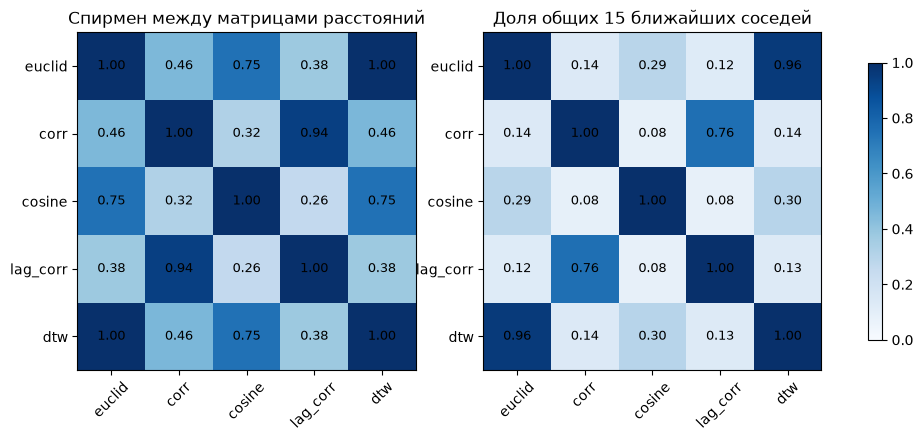

In [15]:
def upper(D):
    return D[np.triu_indices(len(D), k=1)]


def knn_sets(D, k=K_NN):
    D = D.copy()
    np.fill_diagonal(D, np.inf)
    return np.argsort(D, axis=1)[:, :k]


rng = np.random.default_rng(SEED)
sample = rng.choice(n_mo * (n_mo - 1) // 2, size=min(200_000, n_mo * (n_mo - 1) // 2), replace=False)
spearman = pd.DataFrame(index=MEASURES, columns=MEASURES, dtype=float)
nn_overlap = pd.DataFrame(index=MEASURES, columns=MEASURES, dtype=float)
neighbors = {m: knn_sets(DISTANCES[m]) for m in MEASURES}

for a in MEASURES:
    for b in MEASURES:
        spearman.loc[a, b] = stats.spearmanr(upper(DISTANCES[a])[sample], upper(DISTANCES[b])[sample])[0]
        nn_overlap.loc[a, b] = np.mean([len(set(x) & set(y)) / K_NN
                                        for x, y in zip(neighbors[a], neighbors[b])])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, table, title in [(axes[0], spearman, 'Спирмен между матрицами расстояний'),
                         (axes[1], nn_overlap, f'Доля общих {K_NN} ближайших соседей')]:
    im = ax.imshow(table.values, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(len(MEASURES)), MEASURES, rotation=45)
    ax.set_yticks(range(len(MEASURES)), MEASURES)
    for i in range(len(MEASURES)):
        for j in range(len(MEASURES)):
            ax.text(j, i, f'{table.values[i, j]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_title(title)
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

### Кто кого опережает (лаговая мера)
Для пар МО с сильной лаговой связью смотрим знак лага. Строим **ориентированный граф опережения**: ребро $i \to j$, если $i$ опережает $j$ ($\tau^*>0$) и лаговая корреляция входит в верхний 1% всех пар. МО с большой исходящей степенью — локальные «лидеры», чья динамика потом повторяется в других МО. Это кандидаты в центры влияния (региональные центры, агломерации). Гипотезу стоит проверить после добавления типа МО и географии.

In [16]:
best_corr, best_lag = lagged_corr(X_dev, min(MAX_LAG, n_periods // 3))
np.fill_diagonal(best_corr, -1)
threshold = np.quantile(upper(best_corr), 0.99)
lead = (best_corr >= threshold) & (best_lag > 0)

print(f'Порог корреляции (99-й перцентиль): {threshold:.3f}')
print(f'Среди сильных связей: синхронных {np.mean(best_lag[best_corr >= threshold] == 0):.1%}, '
      f'с опережением {np.mean(best_lag[best_corr >= threshold] != 0):.1%}')

leaders = pd.DataFrame({'МО': mo_names,
                        'опережает МО (исх. степень)': lead.sum(axis=1),
                        'следует за МО (вх. степень)': lead.sum(axis=0)})
display(leaders.sort_values('опережает МО (исх. степень)', ascending=False).head(15))

Порог корреляции (99-й перцентиль): 0.879
Среди сильных связей: синхронных 100.0%, с опережением 0.0%


,МО,опережает МО (исх. степень),следует за МО (вх. степень)
1660,городской округ город Ефремов,1,0
1308,внутригородская территория города федерального...,0,0
1307,внутригородская территория города федерального...,0,0
1306,внутригородская территория города федерального...,0,0
1305,внутригородская территория города федерального...,0,0
1304,внутригородская территория города федерального...,0,0
1303,внутригородская территория города федерального...,0,0
1302,внутригородская территория города федерального...,0,0
1301,внутригородская территория города федерального...,0,0
1300,внутригородская территория города федерального...,0,0


## 4. Сеть: правило построения рёбер

**Основное правило: взаимные k ближайших соседей (mutual kNN) с гауссовым весом.**

$$
(i,j)\in E \iff j\in N_k(i)\ \text{и}\ i\in N_k(j), \qquad w_{ij}=\exp\!\left(-\frac{d_{ij}^2}{\sigma^2}\right),
$$

где $N_k(i)$ — $k$ ближайших к $i$ МО по выбранной мере, а $\sigma$ — медиана расстояний до $k$ ближайших соседей (масштаб подбирается по данным).

**Почему так:**
* *Порог по расстоянию* ($d_{ij}<\theta$) плохо работает, когда плотность неравномерна. В «типичной» массе МО каждый связан с сотнями других, а необычные МО остаются изолированными. Итоговая структура в основном отражает плотность, а не сходство.
* *Обычный kNN* даёт каждому узлу хотя бы k рёбер, но создаёт «хабы»: МО в центре облака попадает в соседи ко многим.
* *Взаимный kNN* оставляет только взаимную близость. Хабы исчезают, а нетипичные МО остаются слабо связанными, как и должно быть.
* Гауссов вес превращает расстояние в силу связи от 0 до 1. Близкие соседи весят больше дальних.

Ниже мы количественно сравниваем три правила на одной мере: сколько получается рёбер и компонент, насколько выражены сообщества и насколько меняется разбиение Louvain при смене правила и $k$.

In [17]:
def knn_graph(D, k=K_NN, mutual=True):
    # Матрица весов сети по правилу (взаимных) k ближайших соседей
    n = len(D)
    D = D.copy()
    np.fill_diagonal(D, np.inf)
    nn = np.argsort(D, axis=1)[:, :k]
    A = np.zeros((n, n), dtype=bool)
    A[np.arange(n)[:, None], nn] = True
    A = (A & A.T) if mutual else (A | A.T)
    sigma = np.median(D[np.arange(n)[:, None], nn]) + 1e-12
    return np.where(A, np.exp(-(D / sigma) ** 2), 0.0)


def threshold_graph(D, n_edges):
    # Сеть по порогу расстояния; порог выбран так, чтобы рёбер было n_edges
    d = upper(D)
    thr = np.sort(d)[n_edges - 1]
    A = D <= thr
    np.fill_diagonal(A, False)
    sigma = np.median(d[d <= thr]) + 1e-12
    return np.where(A, np.exp(-(D / sigma) ** 2), 0.0)


def louvain(W, resolution=1.0, seed=SEED):
    G = nx.from_numpy_array(W)
    communities = nx.community.louvain_communities(G, weight='weight', resolution=resolution, seed=seed)
    labels = np.empty(len(W), dtype=int)
    for c, nodes in enumerate(communities):
        labels[list(nodes)] = c
    return labels


def modularity(W, labels):
    # Модулярность Ньюмена для взвешенной сети (метрика MQ)
    two_m = W.sum()
    if two_m == 0:
        return np.nan
    Q = 0.0
    for c in np.unique(labels):
        m = labels == c
        Q += W[np.ix_(m, m)].sum() / two_m - (W[m].sum() / two_m) ** 2
    return Q


def graph_stats(W):
    degree = (W > 0).sum(axis=1)
    n_comp, comp = connected_components(W > 0, directed=False)
    labels = louvain(W)
    return {'рёбер': int((W > 0).sum() // 2), 'ср. степень': degree.mean(),
            'изолированных': int((degree == 0).sum()), 'компонент': n_comp,
            'доля гигантской': np.bincount(comp).max() / len(W),
            'сообществ Louvain': len(np.unique(labels)),
            'модулярность': modularity(W, labels)}, labels

In [18]:
GRAPH_MEASURE = 'dtw'          # мера, на которой сравниваем правила
D = DISTANCES[GRAPH_MEASURE]
rows, graph_labels = [], {}

for k in [5, 10, 15, 30, 50]:
    W_knn = knn_graph(D, k, mutual=False)
    W_mknn = knn_graph(D, k, mutual=True)
    W_thr = threshold_graph(D, int((W_knn > 0).sum() // 2))   # столько же рёбер, сколько у kNN
    for rule, W in [('kNN', W_knn), ('mutual kNN', W_mknn), ('порог', W_thr)]:
        st, labels = graph_stats(W)
        graph_labels[(rule, k)] = labels
        rows.append({'правило': rule, 'k': k, **st})

graph_table = pd.DataFrame(rows)
base = graph_labels[('mutual kNN', K_NN)]
graph_table['ARI с mutual kNN, k=K_NN'] = [adjusted_rand_score(base, graph_labels[(r, k)])
                                          for r, k in zip(graph_table['правило'], graph_table['k'])]
display(graph_table)

,правило,k,рёбер,ср. степень,изолированных,компонент,доля гигантской,сообществ Louvain,модулярность,"ARI с mutual kNN, k=K_NN"
0,kNN,5,7332,7.512,0,1,1.000,17,0.811,0.445
1,mutual kNN,5,2428,2.488,278,337,0.757,370,0.907,0.204
2,порог,5,7332,7.512,1079,1130,0.360,1138,0.596,0.150
3,kNN,10,14292,14.643,0,1,1.000,14,0.764,0.479
4,mutual kNN,10,5228,5.357,114,129,0.921,150,0.836,0.507
5,порог,10,14292,14.643,708,738,0.594,747,0.574,0.200
6,kNN,15,21235,21.757,0,1,1.000,12,0.737,0.360
7,mutual kNN,15,8045,8.243,61,69,0.960,83,0.800,1.000
8,порог,15,21235,21.757,497,518,0.721,530,0.587,0.287
9,kNN,30,41749,42.776,0,1,1.000,11,0.693,0.360


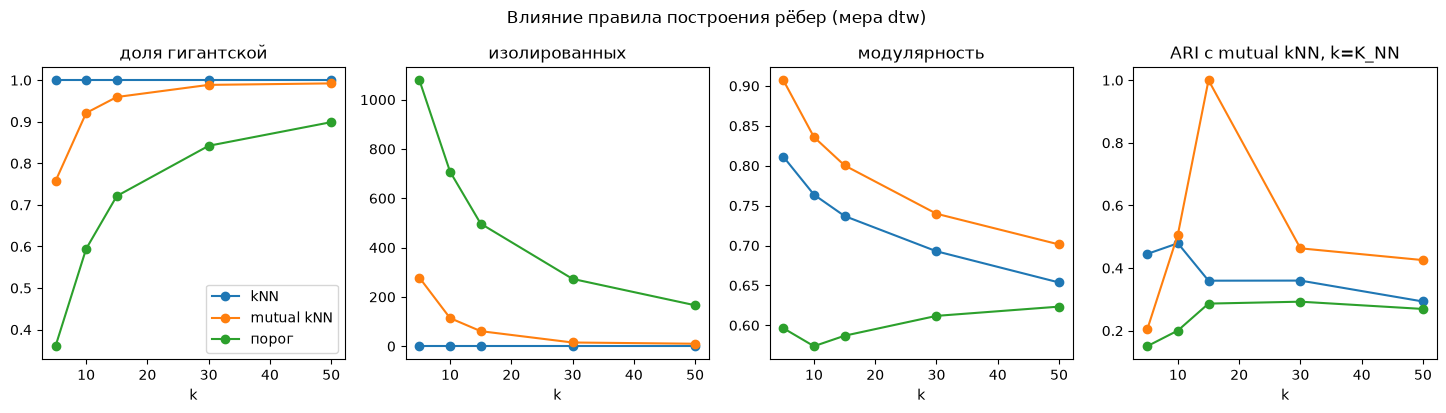

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for rule, g in graph_table.groupby('правило'):
    for ax, col in zip(axes, ['доля гигантской', 'изолированных', 'модулярность', 'ARI с mutual kNN, k=K_NN']):
        ax.plot(g['k'], g[col], marker='o', label=rule)
        ax.set_title(col)
        ax.set_xlabel('k')
axes[0].legend()
plt.suptitle(f'Влияние правила построения рёбер (мера {GRAPH_MEASURE})', y=1.03)
plt.show()

**Как читать таблицу.** Малое $k$ даёт сеть из многих мелких компонент: разбиение дробное и неустойчивое. Большое $k$ соединяет «всех со всеми»: модулярность падает, сообщества размываются. Рабочее $k$ = `K_NN` выбрано там, где гигантская компонента охватывает почти все МО, а модулярность ещё высокая. Столбец ARI показывает, насколько кластеры чувствительны к правилу рёбер. Низкий ARI у порогового правила означает, что при пороге структура определяется в основном плотностью данных.

## 5. Методы кластеризации

Сравниваем методы из трёх семейств. У них разные предположения о том, как выглядит кластер.

| Метод | Работает с | Идея | Особенность |
|---|---|---|---|
| **TimeSeriesKMeans** (Euclid / DBA / soft-DTW) | самими рядами A | k-means, где центр кластера — «средний ряд». DBA усредняет ряды с учётом DTW-выравнивания, soft-DTW — гладкая версия DTW. | Даёт наглядный ряд-центроид. Предпочитает кластеры примерно одного размера. |
| **k-medoids** | матрицей расстояний | Центр кластера — реальное МО (медоид) | Подходит для любой меры. Медоид сразу даёт «типичного представителя». |
| **Иерархическая (average linkage)** | матрицей расстояний | Последовательно сливает ближайшие группы | Любая мера. Склонна выделять выбросы в отдельные мелкие кластеры. |
| **Спектральная** | сетью (раздел 4) | Разрезает сеть по «слабым» рёбрам | Находит кластеры сложной формы |
| **Louvain** | сетью | Максимизирует модулярность | Число кластеров задаётся параметром `resolution` |
| **HDBSCAN** | матрицей расстояний | Кластер = область высокой плотности | Сам определяет число кластеров, нетипичные МО помечает как шум |

Все методы вызываются одной функцией `run_method(method, param, D, series)`. Параметр `param` — это число кластеров k, для Louvain — `resolution`, для HDBSCAN — минимальный размер кластера.

In [20]:
def kmedoids(D, k, seed=SEED, n_iter=100):
    # Простой k-medoids: старт как в k-means++, затем чередуем «назначить → обновить медоиды»
    rng = np.random.default_rng(seed)
    medoids = [rng.integers(len(D))]
    for _ in range(k - 1):
        dist = D[:, medoids].min(axis=1) ** 2
        medoids.append(rng.choice(len(D), p=dist / dist.sum()))
    medoids = np.array(medoids)
    for _ in range(n_iter):
        labels = D[:, medoids].argmin(axis=1)
        new = medoids.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members):
                new[c] = members[D[np.ix_(members, members)].sum(axis=1).argmin()]
        if np.array_equal(new, medoids):
            break
        medoids = new
    return D[:, medoids].argmin(axis=1)


def run_method(method, param, D, series=None, seed=SEED):
    # Одна точка входа для всех методов. Возвращает метки кластеров (−1 = шум)
    if method != 'louvain':
        param = int(param)           # число кластеров или мин. размер кластера — целое
    if method == 'kmedoids':
        return kmedoids(D, param, seed)
    if method == 'agglomerative':
        return AgglomerativeClustering(n_clusters=param, metric='precomputed', linkage='average').fit_predict(D)
    if method == 'spectral':
        return SpectralClustering(n_clusters=param, affinity='precomputed',
                                  random_state=seed).fit_predict(knn_graph(D))
    if method == 'louvain':
        return louvain(knn_graph(D), resolution=param, seed=seed)
    if method == 'hdbscan':
        return HDBSCAN(min_cluster_size=param, metric='precomputed', copy=True).fit_predict(D)
    if method == 'ts_kmeans_euclid':
        return TimeSeriesKMeans(n_clusters=param, metric='euclidean', n_init=3,
                                random_state=seed).fit_predict(series)
    if method == 'ts_kmeans_dba':
        return TimeSeriesKMeans(n_clusters=param, metric='dtw', n_init=1, max_iter=10,
                                max_iter_barycenter=10, random_state=seed,
                                metric_params={'global_constraint': 'sakoe_chiba',
                                               'sakoe_chiba_radius': DTW_RADIUS}).fit_predict(series)
    if method == 'ts_kmeans_softdtw':
        return TimeSeriesKMeans(n_clusters=param, metric='softdtw', metric_params={'gamma': .01},
                                max_iter=10, random_state=seed).fit_predict(series)
    raise ValueError(method)

## 6. Оценка качества (ICVI) и выбор числа кластеров

**Как считаем индексы.**
* **SW** — по матрице расстояний той меры, на которой строилось разбиение.
* **CH, S_Dbw** требуют координат точек. Для каждой меры строим 10-мерное MDS-вложение её матрицы расстояний и считаем индексы в нём. Для евклидовой меры это точное представление, для DTW и корреляций приближение: отрицательные собственные значения отбрасываются.
* **AVI, AVU** — в общем пространстве стандартизованных атрибутов `F` (раздел 2).
* **MQ** — модулярность разбиения на сети mutual kNN этой меры.
* Для HDBSCAN индексы считаются без точек-шума, доля шума выводится отдельно.

**Сопоставимость.** SW, CH, S_Dbw и MQ корректно сравнивать *между разными k для одной меры*: у разных мер разная геометрия. Для сравнения *мер между собой* используем AVI и AVU (общее пространство атрибутов) и устойчивость.

**Выбор k.** Для каждой пары «мера × метод» ранжируем все k по каждому из 6 индексов и складываем места (метод Борда). Вырожденные разбиения исключаем: один кластер больше 80% МО или кластер меньше 1% МО. Такие разбиения формально бывают «хорошими» (например, «все МО + несколько выбросов»), но экономически бесполезны.

In [21]:
def mds_embedding(D, dim=10):
    # Классическое MDS: координаты точек, расстояния между которыми близки к D
    n = len(D)
    J = np.eye(n) - 1.0 / n
    B = -0.5 * J @ (D ** 2) @ J
    vals, vecs = eigh(B, subset_by_index=[n - dim, n - 1])
    return vecs[:, ::-1] * np.sqrt(np.clip(vals[::-1], 0, None))


def s_dbw(X, labels):
    # S_Dbw (Halkidi & Vazirgiannis, 2001): рыхлость кластеров + плотность между ними
    ks = np.unique(labels)
    centers = np.array([X[labels == c].mean(axis=0) for c in ks])
    sigma_norms = np.array([np.linalg.norm(X[labels == c].var(axis=0)) for c in ks])
    scat = sigma_norms.mean() / np.linalg.norm(X.var(axis=0))
    stdev = np.sqrt(sigma_norms.sum()) / len(ks)

    def density(point, mask):
        return np.sum(np.linalg.norm(X[mask] - point, axis=1) <= stdev)

    dens, pairs = 0.0, 0
    for i in range(len(ks)):
        for j in range(i + 1, len(ks)):
            mask = (labels == ks[i]) | (labels == ks[j])
            middle = density((centers[i] + centers[j]) / 2, mask)
            dens += middle / max(density(centers[i], mask), density(centers[j], mask), 1)
            pairs += 1
    return scat + dens / pairs


def attribute_indices(labels, D_attr):
    # AVI: ср. расстояние атрибутов внутри кластеров, AVU: между кластерами (оба / общее среднее)
    same = labels[:, None] == labels[None, :]
    off_diag = ~np.eye(len(labels), dtype=bool)
    base = D_attr[off_diag].mean()
    return D_attr[same & off_diag].mean() / base, D_attr[~same].mean() / base


def evaluate(labels, D, X_emb, W):
    keep = labels >= 0                                   # без шума HDBSCAN
    lab = labels[keep]
    sizes = np.unique(lab, return_counts=True)[1] / len(labels)
    row = {'k_fact': len(sizes), 'noise': 1 - keep.mean(),
           'min_share': sizes.min() if len(sizes) else np.nan,
           'max_share': sizes.max() if len(sizes) else np.nan}
    if len(sizes) < 2:
        return row
    D_keep = D if keep.all() else D[np.ix_(keep, keep)]
    DA_keep = D_ATTR if keep.all() else D_ATTR[np.ix_(keep, keep)]
    row['SW'] = silhouette_score(D_keep, lab, metric='precomputed')
    row['CH'] = calinski_harabasz_score(X_emb[keep], lab)
    row['S_Dbw'] = s_dbw(X_emb[keep], lab)
    row['AVI'], row['AVU'] = attribute_indices(lab, DA_keep)
    row['MQ'] = modularity(W, labels)
    return row


# True: больше = лучше
METRICS = {'SW': True, 'CH': True, 'S_Dbw': False, 'AVI': False, 'AVU': True, 'MQ': True}

### Полный перебор: мера × метод × параметр
Это самая долгая ячейка. Разбиения сохраняются в `PARTITIONS`, таблица индексов — в `results/icvi_all.csv`.

In [22]:
CONFIGS = []
for m in MEASURES:
    for method in ['kmedoids', 'agglomerative', 'spectral']:
        CONFIGS += [(m, method, k) for k in K_RANGE]
    CONFIGS += [(m, 'louvain', r) for r in LOUVAIN_RES]
    CONFIGS.append((m, 'hdbscan', HDBSCAN_MIN_SIZE))
CONFIGS += [('euclid', 'ts_kmeans_euclid', k) for k in K_RANGE]
if RUN_SLOW_TSKMEANS:
    CONFIGS += [('dtw', 'ts_kmeans_dba', k) for k in K_RANGE]
    CONFIGS += [('dtw', 'ts_kmeans_softdtw', k) for k in K_RANGE]

EMBEDDINGS = {m: mds_embedding(DISTANCES[m]) for m in MEASURES}
GRAPHS = {m: knn_graph(DISTANCES[m]) for m in MEASURES}

PARTITIONS, rows = {}, []
for i, (m, method, param) in enumerate(CONFIGS):
    t0 = time.time()
    labels = run_method(method, param, DISTANCES[m], X_level)
    seconds = time.time() - t0
    PARTITIONS[(m, method, param)] = labels
    rows.append({'measure': m, 'method': method, 'param': param, 'seconds': seconds,
                 **evaluate(labels, DISTANCES[m], EMBEDDINGS[m], GRAPHS[m])})
    if (i + 1) % 25 == 0:
        print(f'{i + 1}/{len(CONFIGS)} готово')

icvi = pd.DataFrame(rows)
icvi['degenerate'] = (icvi['max_share'] > MAX_CLUSTER_SHARE) | (icvi['min_share'] < MIN_CLUSTER_SHARE)
icvi.to_csv(OUT_DIR / 'icvi_all.csv', index=False)
print('Доля вырожденных разбиений по методам:')
display(icvi.groupby('method')['degenerate'].mean().to_frame())

25/287 готово
50/287 готово
75/287 готово
100/287 готово
125/287 готово
150/287 готово
175/287 готово
200/287 готово
225/287 готово
250/287 готово
275/287 готово
Доля вырожденных разбиений по методам:


,degenerate
method,
agglomerative,0.871
hdbscan,0.000
kmedoids,0.171
louvain,1.000
spectral,1.000
ts_kmeans_dba,0.000
ts_kmeans_euclid,0.071
ts_kmeans_softdtw,0.143


### Индексы в зависимости от числа кластеров
Для каждой меры — шесть графиков. Ищем k, на котором несколько индексов одновременно дают пик (SW, CH, AVU, MQ) или провал (S_Dbw, AVI). Пустые (выколотые) маркеры — вырожденные разбиения.

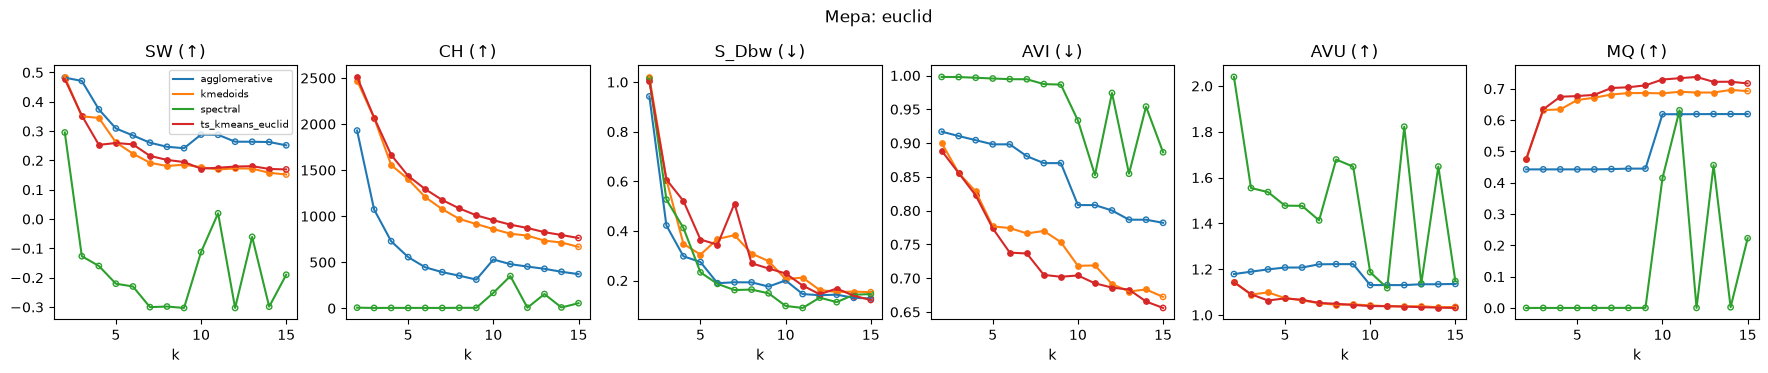

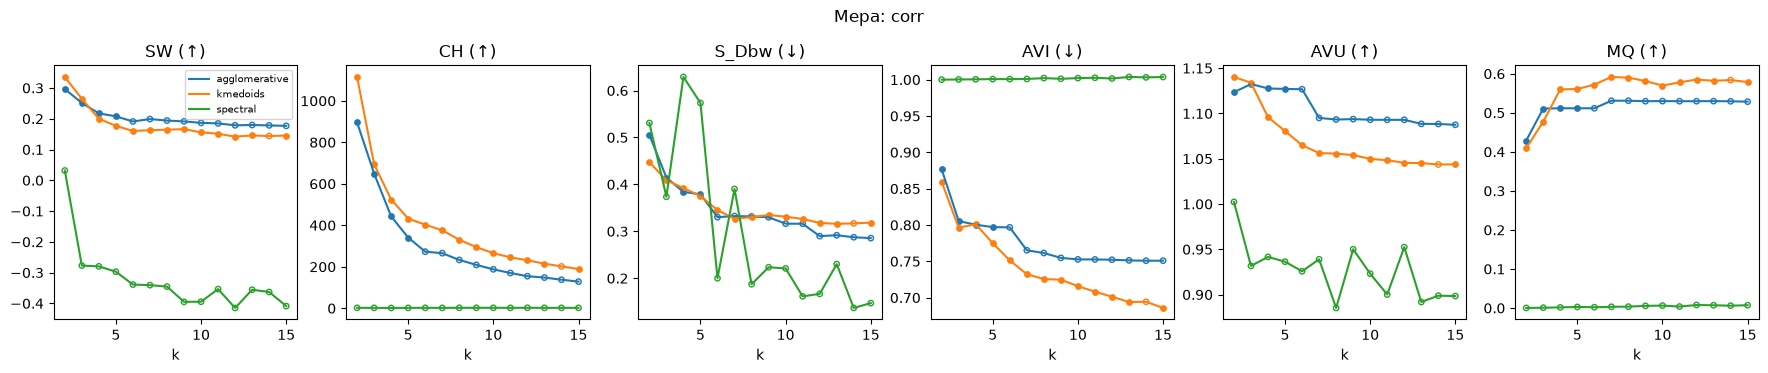

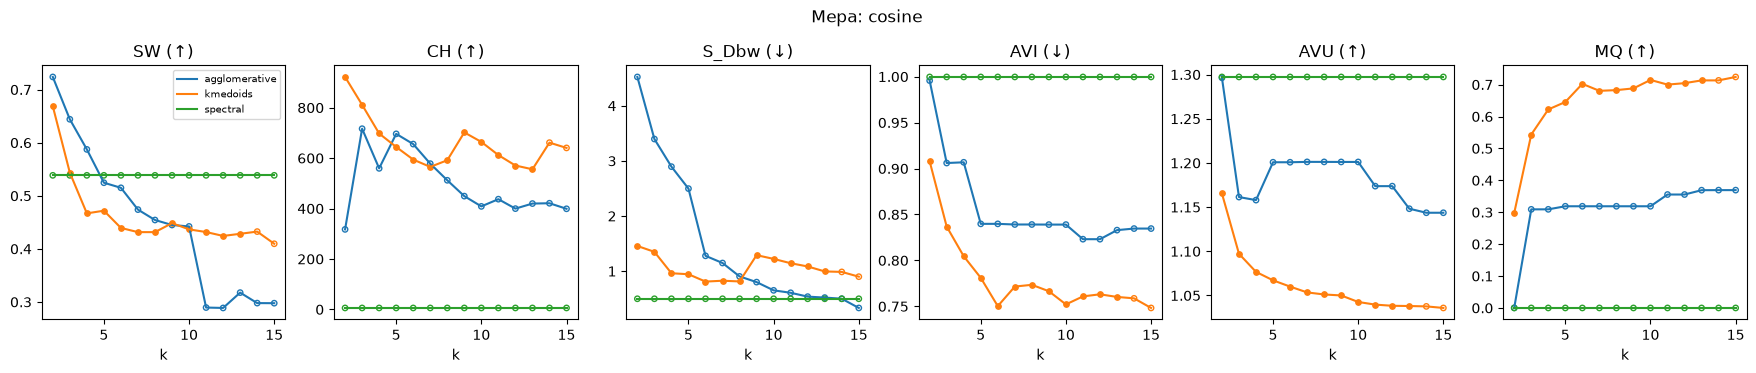

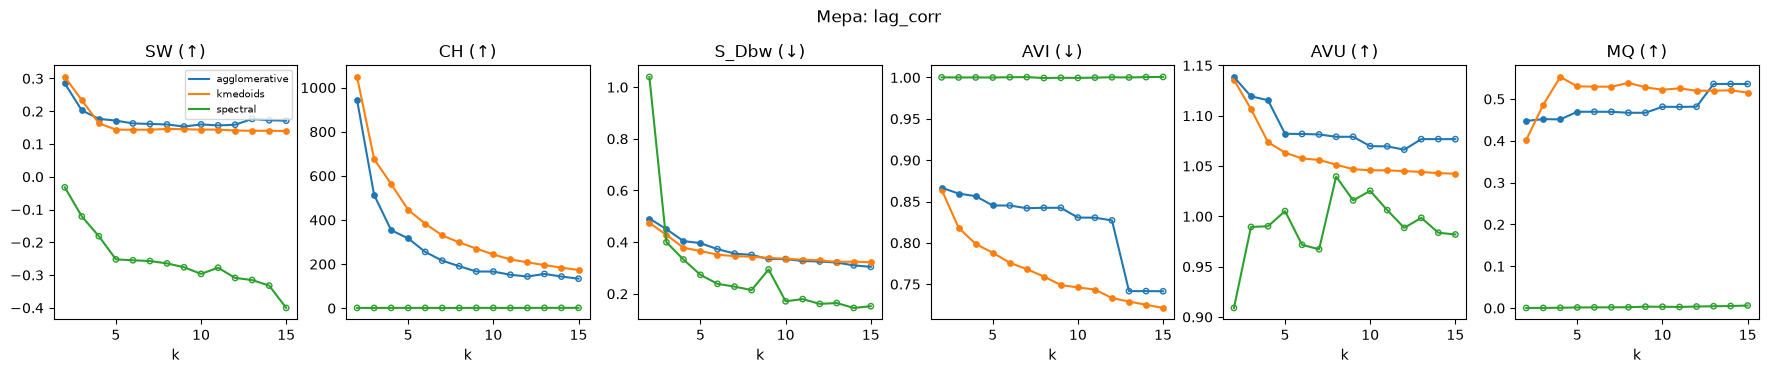

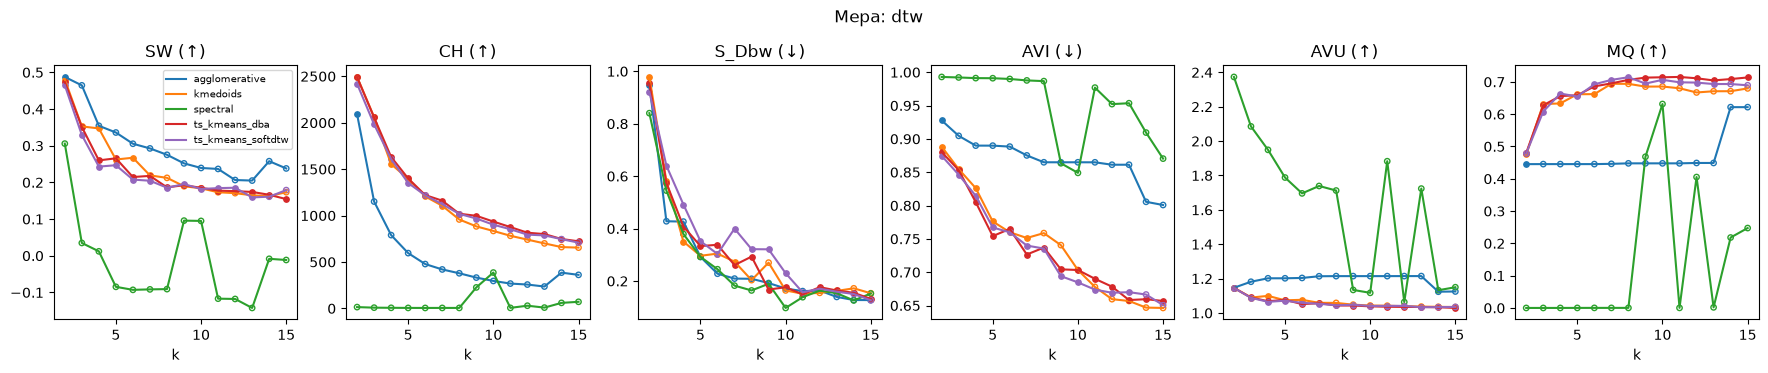

In [24]:
k_methods = ['kmedoids', 'agglomerative', 'spectral', 'ts_kmeans_euclid', 'ts_kmeans_dba', 'ts_kmeans_softdtw']
for m in MEASURES:
    sub = icvi[(icvi['measure'] == m) & icvi['method'].isin(k_methods)]
    fig, axes = plt.subplots(1, 6, figsize=(22, 3.3))
    for method, g in sub.groupby('method'):
        for ax, metric in zip(axes, METRICS):
            line, = ax.plot(g['param'], g[metric], label=method)
            ok = ~g['degenerate']
            ax.scatter(g['param'][ok], g[metric][ok], color=line.get_color(), s=15)
            ax.scatter(g['param'][~ok], g[metric][~ok], facecolors='none', edgecolors=line.get_color(), s=15)
            ax.set_title(f"{metric} ({'↑' if METRICS[metric] else '↓'})")
            ax.set_xlabel('k')
    axes[0].legend(fontsize=7)
    plt.suptitle(f'Мера: {m}', y=1.05)
    plt.show()

In [25]:
def borda_best(g):
    # Лучший параметр по сумме мест во всех индексах (среди невырожденных)
    g = g[~g['degenerate']].dropna(subset=list(METRICS))
    if g.empty:
        return None
    score = sum(g[m].rank(ascending=not higher) for m, higher in METRICS.items())
    return g.loc[score.idxmin()]


best = pd.DataFrame([r for _, g in icvi.groupby(['measure', 'method']) if (r := borda_best(g)) is not None])
best = best.reset_index(drop=True).infer_objects()
print('Лучший параметр для каждой пары «мера × метод»:')
display(best[['measure', 'method', 'param', 'k_fact', 'noise', 'min_share', 'max_share', *METRICS, 'seconds']])

Лучший параметр для каждой пары «мера × метод»:


,measure,method,param,k_fact,noise,min_share,max_share,SW,CH,S_Dbw,AVI,AVU,MQ,seconds
0,corr,agglomerative,4.000,4,0.000,0.016,0.473,0.217,442.999,0.384,0.800,1.128,0.512,0.037
1,corr,hdbscan,20.000,2,0.668,0.024,0.309,0.737,442.020,0.598,0.835,2.084,0.479,0.081
2,corr,kmedoids,7.000,7,0.000,0.060,0.243,0.163,375.744,0.327,0.732,1.056,0.592,0.011
3,cosine,hdbscan,20.000,2,0.422,0.076,0.502,0.853,1529.415,0.443,0.900,1.335,0.343,0.080
4,cosine,kmedoids,6.000,6,0.000,0.047,0.275,0.439,594.258,0.811,0.750,1.060,0.702,0.024
5,dtw,agglomerative,2.000,2,0.000,0.208,0.792,0.488,2090.882,0.949,0.928,1.147,0.445,0.036
6,dtw,hdbscan,20.000,2,0.833,0.038,0.129,0.648,786.842,0.296,0.746,1.467,0.439,0.082
7,dtw,kmedoids,4.000,4,0.000,0.034,0.500,0.347,1554.487,0.350,0.826,1.100,0.633,0.018
8,dtw,ts_kmeans_dba,11.000,11,0.000,0.029,0.155,0.178,876.135,0.149,0.690,1.036,0.715,4.344
9,dtw,ts_kmeans_softdtw,6.000,6,0.000,0.042,0.260,0.208,1218.071,0.303,0.760,1.059,0.693,1526.795


### Устойчивость
Хороший тип экономики не должен исчезать, если убрать из выборки часть МО. Берём 80% МО `N_BOOT` раз, заново кластеризуем и сравниваем с исходным разбиением на тех же МО (ARI). Значение выше 0.8 — устойчиво, ниже 0.5 — разбиение во многом случайно. Для DBA и soft-DTW проверка очень долгая, поэтому по умолчанию пропускается.

In [26]:
def stability(m, method, param, n_boot=N_BOOT, frac=0.8):
    full = PARTITIONS[(m, method, param)]
    rng = np.random.default_rng(SEED)
    scores = []
    for b in range(n_boot):
        idx = np.sort(rng.choice(n_mo, int(frac * n_mo), replace=False))
        lab = run_method(method, param, DISTANCES[m][np.ix_(idx, idx)], X_level[idx], seed=SEED + b + 1)
        scores.append(adjusted_rand_score(full[idx], lab))
    return np.mean(scores), np.std(scores)


stab = []
for _, r in best.iterrows():
    if r['method'] in ('ts_kmeans_dba', 'ts_kmeans_softdtw'):
        stab.append((np.nan, np.nan))
    else:
        stab.append(stability(r['measure'], r['method'], r['param']))
best['stability'], best['stability_std'] = zip(*stab)
best.to_csv(OUT_DIR / 'icvi_best.csv', index=False)
display(best[['measure', 'method', 'param', 'k_fact', 'SW', 'AVI', 'AVU', 'MQ', 'stability', 'stability_std']])

,measure,method,param,k_fact,SW,AVI,AVU,MQ,stability,stability_std
0,corr,agglomerative,4.000,4,0.217,0.800,1.128,0.512,0.699,0.045
1,corr,hdbscan,20.000,2,0.737,0.835,2.084,0.479,0.907,0.032
2,corr,kmedoids,7.000,7,0.163,0.732,1.056,0.592,0.520,0.067
3,cosine,hdbscan,20.000,2,0.853,0.900,1.335,0.343,0.817,0.075
4,cosine,kmedoids,6.000,6,0.439,0.750,1.060,0.702,0.557,0.118
5,dtw,agglomerative,2.000,2,0.488,0.928,1.147,0.445,0.444,0.449
6,dtw,hdbscan,20.000,2,0.648,0.746,1.467,0.439,0.912,0.021
7,dtw,kmedoids,4.000,4,0.347,0.826,1.100,0.633,0.700,0.182
8,dtw,ts_kmeans_dba,11.000,11,0.178,0.690,1.036,0.715,NaN,NaN
9,dtw,ts_kmeans_softdtw,6.000,6,0.208,0.760,1.059,0.693,NaN,NaN


### Сравнение мер и методов между собой
Матрица ARI между лучшими разбиениями показывает, находят ли разные подходы одни и те же группы. Если несколько независимых подходов (например, DTW + k-medoids и евклид + TimeSeriesKMeans) дают похожие разбиения, найденные типы экономик — свойство данных, а не артефакт метода.

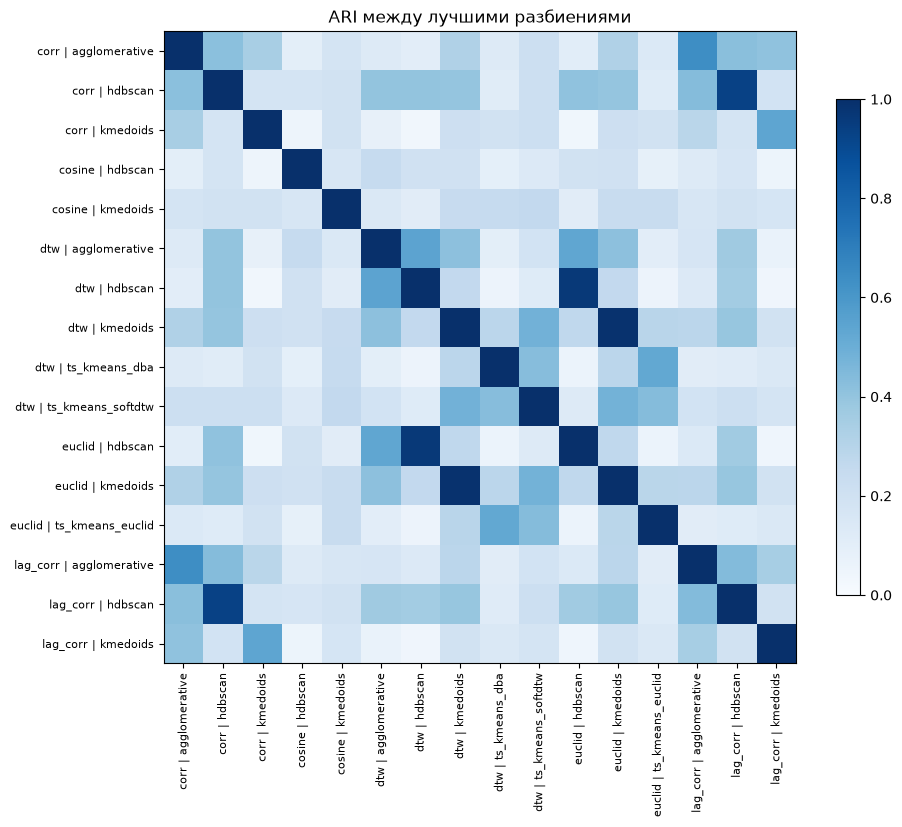

In [27]:
keys = [(r['measure'], r['method'], r['param']) for _, r in best.iterrows()]
names = [f'{m} | {method}' for m, method, _ in keys]
ari = np.array([[adjusted_rand_score(PARTITIONS[a], PARTITIONS[b]) for b in keys] for a in keys])

fig, ax = plt.subplots(figsize=(0.45 * len(keys) + 3, 0.45 * len(keys) + 2))
im = ax.imshow(ari, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(keys)), names, rotation=90, fontsize=8)
ax.set_yticks(range(len(keys)), names, fontsize=8)
plt.colorbar(im, shrink=0.7)
ax.set_title('ARI между лучшими разбиениями')
plt.show()

### Итоговый выбор
Автоматическое правило: среди невырожденных разбиений берём конфигурацию с лучшей суммой мест по трём критериям, сопоставимым между мерами: **AVI↓, AVU↑, устойчивость↑**. Это разумное значение по умолчанию. Его можно переопределить вручную в следующей ячейке, если по графикам и интерпретации другой вариант выглядит убедительнее. Обоснование выбора стоит записать в выводах.

In [28]:
cand = best.dropna(subset=['stability']).copy()
cand['score'] = (cand['AVI'].rank() + cand['AVU'].rank(ascending=False)
                 + cand['stability'].rank(ascending=False))
display(cand.sort_values('score')[['measure', 'method', 'param', 'k_fact', 'AVI', 'AVU', 'stability', 'SW', 'MQ', 'score']].head(10))

top = cand.sort_values('score').iloc[0]
FINAL_MEASURE, FINAL_METHOD, FINAL_PARAM = top['measure'], top['method'], top['param']
# FINAL_MEASURE, FINAL_METHOD, FINAL_PARAM = 'dtw', 'kmedoids', 6    # ручной выбор
FINAL_PARAM = int(FINAL_PARAM) if FINAL_METHOD != 'louvain' else float(FINAL_PARAM)

final_labels = PARTITIONS[(FINAL_MEASURE, FINAL_METHOD, FINAL_PARAM)]
print(f'Итог: мера={FINAL_MEASURE}, метод={FINAL_METHOD}, параметр={FINAL_PARAM}, '
      f'кластеров={len(np.unique(final_labels[final_labels >= 0]))}')

,measure,method,param,k_fact,AVI,AVU,stability,SW,MQ,score
6,dtw,hdbscan,20.000,2,0.746,1.467,0.912,0.648,0.439,9.000
10,euclid,hdbscan,20.000,2,0.731,1.432,0.905,0.645,0.443,10.000
14,lag_corr,hdbscan,20.000,2,0.800,1.882,0.949,0.687,0.483,10.000
1,corr,hdbscan,20.000,2,0.835,2.084,0.907,0.737,0.479,15.000
0,corr,agglomerative,4.000,4,0.800,1.128,0.699,0.217,0.512,22.000
3,cosine,hdbscan,20.000,2,0.900,1.335,0.817,0.853,0.343,23.000
7,dtw,kmedoids,4.000,4,0.826,1.100,0.700,0.347,0.633,24.000
12,euclid,ts_kmeans_euclid,12.000,12,0.686,1.037,0.582,0.179,0.738,25.000
2,corr,kmedoids,7.000,7,0.732,1.056,0.520,0.163,0.592,28.000
4,cosine,kmedoids,6.000,6,0.750,1.060,0.557,0.439,0.702,28.000


Итог: мера=dtw, метод=hdbscan, параметр=20, кластеров=2


## 7. Динамика: как меняются группы во времени

**Динамическая сеть.** Сеть в момент $t$ строится по окну из `WINDOW` месяцев $[t-W+1,\ t]$ со сдвигом `STEP`. Для каждого окна считаем расстояния той же функцией `compute_distance`, строим сеть mutual kNN и кластеризуем итоговым методом. Атрибуты узлов (`make_attributes`) тоже пересчитываются по окну. Так получается последовательность атрибутированных сетей $G_t=(V, E_t, W_t, F_t)$.

**Сглаживание (эволюционная кластеризация, Chakrabarti и др., 2006).** Короткие окна шумные, и без сглаживания МО «прыгают» между кластерами из-за случайных колебаний. Используем сглаженное расстояние:
$$\tilde D_t=(1-\alpha)\,D_t+\alpha\,\tilde D_{t-1}.$$
При $\alpha=0$ каждое окно независимо. Чем больше $\alpha$, тем сильнее учитывается история. Ниже сравниваем $\alpha=0$ и $\alpha=$ `ALPHA` по двум показателям: качество разбиения в окне (SW) и согласованность соседних окон (ARI).

**Сопоставление кластеров.** Номера кластеров в разных окнах произвольны. Кластеры окна $t$ сопоставляем с кластерами окна $t-1$ по максимальному числу общих МО (венгерский алгоритм), после этого «кластер 2» означает одну и ту же группу во всех окнах.

**События жизненного цикла** (по Greene и др., 2010). Для кластера $A$ в окне $t-1$ и $B$ в окне $t$ считаем долю общих МО. Порог $\theta=0.3$.

| Событие | Правило |
|---|---|
| продолжение | у $B$ ровно один предшественник $A$ (доля МО из $A$ в $B \ge \theta$). Дополнительно отмечаем рост или сжатие, если размер изменился больше чем на 20%. |
| отделение части | у $B$ один предшественник $A$, но $B$ не основной преемник $A$: от кластера откололась группа МО |
| слияние | у $B$ два и более предшественника |
| расщепление | у $A$ два и более преемника (доля МО из $A$, ушедших в $B$, $\ge \theta$) |
| появление | у $B$ нет предшественников |
| исчезновение | у $A$ нет преемников |

**Показатели динамики:** ARI между соседними окнами, стабильность каждого МО (доля переходов, при которых МО осталось в своём кластере), матрица переходов между кластерами.

In [29]:
def align_labels(prev, new):
    # Перенумеровать кластеры new так, чтобы они максимально совпадали с prev
    a_ids, b_ids = np.unique(prev), np.unique(new)
    overlap = np.array([[np.sum((prev == a) & (new == b)) for b in b_ids] for a in a_ids])
    rows, cols = linear_sum_assignment(-overlap)
    mapping = {b_ids[c]: a_ids[r] for r, c in zip(rows, cols) if overlap[r, c] > 0}
    next_id = max(prev.max(), new.max()) + 1
    for b in b_ids:
        if b not in mapping:
            mapping[b] = next_id
            next_id += 1
    return np.array([mapping[b] for b in new])


def lifecycle_events(prev, new, theta=0.3):
    # События между соседними окнами; метки new уже сопоставлены с prev (align_labels)
    ids = lambda xs: ', '.join(str(int(x)) for x in xs)
    events = []
    for a in np.unique(prev):
        A = prev == a
        successors = [b for b in np.unique(new) if np.sum(A & (new == b)) / A.sum() >= theta]
        if not successors:
            events.append(('исчезновение', ids([a]), ''))
        elif len(successors) >= 2:
            events.append(('расщепление', ids([a]), ids(successors)))
    for b in np.unique(new):
        B = new == b
        preds = [a for a in np.unique(prev) if np.sum(B & (prev == a)) / B.sum() >= theta]
        if not preds:
            events.append(('появление', '', ids([b])))
        elif len(preds) >= 2:
            events.append(('слияние', ids(preds), ids([b])))
        elif preds[0] != b:
            events.append(('отделение части', ids(preds), ids([b])))
        else:
            change = B.sum() / np.sum(prev == b)
            kind = 'продолжение' + (' (рост)' if change > 1.2 else ' (сжатие)' if change < 0.8 else '')
            events.append((kind, ids([b]), ids([b])))
    return events


def track_clusters(alpha):
    labels_t, quality, events, graphs = [], [], [], []
    D_smooth, prev = None, None
    for s in range(0, n_periods - WINDOW + 1, STEP):
        D = compute_distance(FINAL_MEASURE, s, s + WINDOW)
        D_smooth = D if D_smooth is None else (1 - alpha) * D + alpha * D_smooth
        labels = run_method(FINAL_METHOD, FINAL_PARAM, D_smooth, X_level[:, s:s + WINDOW])
        if prev is not None:
            labels = align_labels(prev, labels)
            end = periods[s + WINDOW - 1].strftime('%Y-%m')
            events += [(end, *e) for e in lifecycle_events(prev, labels)]
        keep = labels >= 0
        quality.append(silhouette_score(D[np.ix_(keep, keep)], labels[keep], metric='precomputed')
                       if len(np.unique(labels[keep])) > 1 else np.nan)
        graphs.append(knn_graph(D_smooth))
        labels_t.append(labels)
        prev = labels
    return np.array(labels_t), np.array(quality), events, graphs


window_ends = [periods[s + WINDOW - 1].strftime('%Y-%m') for s in range(0, n_periods - WINDOW + 1, STEP)]
print(f'Окон: {len(window_ends)} ({window_ends[0]} … {window_ends[-1]})')

dyn = {}
for alpha in [0.0, ALPHA]:
    t0 = time.time()
    dyn[alpha] = track_clusters(alpha)
    print(f'alpha={alpha}: {time.time() - t0:.1f} с')

Окон: 19 (2023-06 … 2024-12)
alpha=0.0: 1219.6 с
alpha=0.3: 1227.0 с


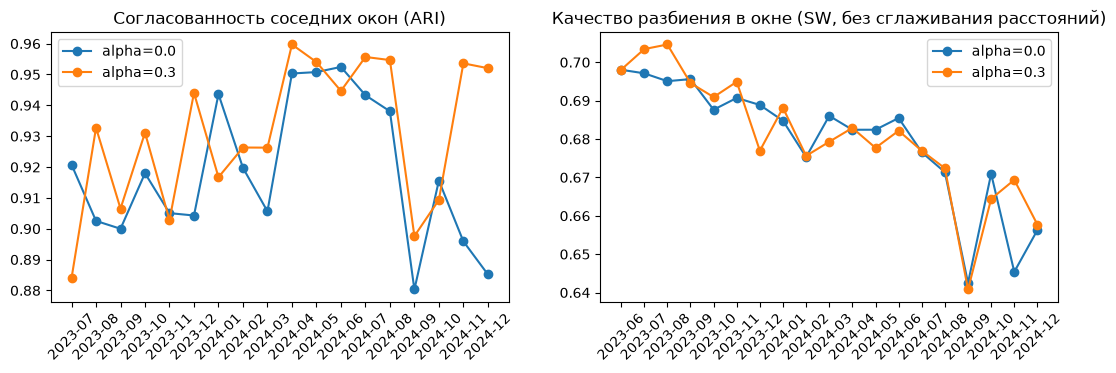

,alpha,ARI соседних окон (ср.),SW в окне (ср.),"доля МО, ни разу не сменивших кластер"
0,0.000,0.918,0.680,0.871
1,0.300,0.931,0.681,0.877


In [30]:
def consecutive_ari(labels_t):
    return np.array([adjusted_rand_score(labels_t[i], labels_t[i + 1]) for i in range(len(labels_t) - 1)])


fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
summary = []
for alpha, (labels_t, quality, _, _) in dyn.items():
    ari_t = consecutive_ari(labels_t)
    axes[0].plot(window_ends[1:], ari_t, marker='o', label=f'alpha={alpha}')
    axes[1].plot(window_ends, quality, marker='o', label=f'alpha={alpha}')
    summary.append({'alpha': alpha, 'ARI соседних окон (ср.)': ari_t.mean(),
                    'SW в окне (ср.)': np.nanmean(quality),
                    'доля МО, ни разу не сменивших кластер': np.mean((labels_t == labels_t[0]).all(axis=0))})
axes[0].set_title('Согласованность соседних окон (ARI)')
axes[1].set_title('Качество разбиения в окне (SW, без сглаживания расстояний)')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
plt.show()
display(pd.DataFrame(summary))

Хорошее $\alpha$ заметно повышает ARI соседних окон и почти не снижает SW. Это значит, что сглаживание убирает шум, а не реальные изменения. Дальше используем `ALPHA`.

In [31]:
labels_t, quality_t, events, graphs_t = dyn[ALPHA]
labels_df = pd.DataFrame(labels_t.T, index=mo_names, columns=window_ends)

# Стабильность МО: доля переходов между окнами без смены кластера
stability_mo = (labels_t[1:] == labels_t[:-1]).mean(axis=0)
print(f'Средняя стабильность МО: {stability_mo.mean():.2f}; '
      f'МО, сменивших кластер хотя бы раз: {np.mean(stability_mo < 1):.1%}')

# Матрица переходов: из какого кластера в какой переходят МО за один шаг
transitions = pd.crosstab(labels_t[:-1].ravel(), labels_t[1:].ravel(),
                          rownames=['из'], colnames=['в'], normalize='index')
print('Вероятности перехода между кластерами за один шаг окна:')
display(transitions.round(3))

events_df = pd.DataFrame(events, columns=['окно', 'событие', 'из кластера', 'в кластер'])
print('События жизненного цикла кластеров (без простых продолжений):')
display(events_df[events_df['событие'] != 'продолжение'])
display(events_df['событие'].value_counts().to_frame())

print('Наименее стабильные МО (часто меняют тип):')
display(pd.DataFrame({'стабильность': stability_mo,
                      'кластеры по окнам': [' → '.join(map(str, r)) for r in labels_t.T]},
                     index=mo_names).sort_values('стабильность').head(15))

Средняя стабильность МО: 0.98; МО, сменивших кластер хотя бы раз: 12.3%
Вероятности перехода между кластерами за один шаг окна:


в,-1,0,1,3
из,,,,
-1,0.994,0.004,0.002,0.001
0,0.206,0.791,0.003,0.000
1,0.019,0.001,0.980,0.000
3,1.000,0.000,0.000,0.000


События жизненного цикла кластеров (без простых продолжений):


,окно,событие,из кластера,в кластер
1,2023-07,продолжение (сжатие),0,0
12,2023-11,расщепление,0,"-1, 0"
14,2023-11,продолжение (сжатие),0,0
19,2024-01,расщепление,0,"-1, 0"
21,2024-01,продолжение (сжатие),0,0
24,2024-02,слияние,"-1, 0",0
26,2024-03,расщепление,0,"-1, 0"
28,2024-03,продолжение (сжатие),0,0
34,2024-05,продолжение (сжатие),0,0
37,2024-06,продолжение (рост),0,0


,count
событие,
продолжение,47
продолжение (сжатие),5
расщепление,3
слияние,1
продолжение (рост),1
отделение части,1


Наименее стабильные МО (часто меняют тип):


,стабильность,кластеры по окнам
городской округ город Алексин,0.389,-1 → -1 → -1 → 0 → 0 → -1 → 0 → -1 → 0 → -1 → ...
городской округ Кинель,0.556,0 → 0 → 0 → 0 → 0 → -1 → 0 → -1 → 0 → 0 → 0 → ...
городской округ город Оренбург,0.611,0 → -1 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 0...
городской округ город Ульяновск,0.611,0 → 0 → -1 → -1 → -1 → -1 → 0 → -1 → 0 → 0 → 0...
городской округ Первоуральск,0.611,0 → 0 → 0 → 0 → 0 → -1 → 0 → -1 → 0 → -1 → -1 ...
Вольский муниципальный район,0.611,0 → 0 → -1 → 0 → 0 → -1 → -1 → -1 → 0 → -1 → -...
городской округ город Дзержинск,0.667,-1 → -1 → -1 → 0 → 0 → 0 → 0 → 0 → 0 → 0 → 1 →...
внутригородская территория города федерального значения поселение Десеновское,0.667,1 → -1 → -1 → 1 → 1 → 1 → 1 → -1 → 1 → -1 → -1...
городской округ Верхняя Пышма,0.667,1 → -1 → -1 → 1 → 1 → 1 → 1 → -1 → 1 → 1 → 1 →...
городской округ город Ярославль,0.667,-1 → -1 → -1 → 1 → -1 → -1 → -1 → -1 → 0 → -1 ...


### Экспорт динамической атрибутированной сети
Сохраняем в `results/` файлы для последующей визуализации:
* `dynamic_nodes.csv` — окно, МО, кластер, атрибуты МО в этом окне;
* `dynamic_edges.csv` — окно, пара МО, вес ребра;
* `dynamic_events.csv` — события жизненного цикла.

In [32]:
node_rows, edge_rows = [], []
for w, (s, end) in enumerate(zip(range(0, n_periods - WINDOW + 1, STEP), window_ends)):
    F_w = make_attributes(X_raw[:, s:s + WINDOW])
    F_w.insert(0, 'cluster', labels_t[w])
    F_w.insert(0, 'window_end', end)
    node_rows.append(F_w.rename_axis('mo').reset_index())
    i, j = np.nonzero(np.triu(graphs_t[w], k=1))
    edge_rows.append(pd.DataFrame({'window_end': end, 'source': mo_names[i], 'target': mo_names[j],
                                   'weight': graphs_t[w][i, j]}))

pd.concat(node_rows).to_csv(OUT_DIR / 'dynamic_nodes.csv', index=False)
pd.concat(edge_rows).to_csv(OUT_DIR / 'dynamic_edges.csv', index=False)
events_df.to_csv(OUT_DIR / 'dynamic_events.csv', index=False)
print('Сохранено:', [p.name for p in OUT_DIR.glob('dynamic_*.csv')])

Сохранено: ['dynamic_edges.csv', 'dynamic_events.csv', 'dynamic_nodes.csv']


## 8. Интерпретация: какие типы локальных экономик получились

Интерпретируем итоговое разбиение за весь период. Шаги:

1. **Профиль кластера:** средние траты по категориям в рублях, структура (доли) и **lift**, то есть отношение к среднему по всем МО. Lift 1.3 по маркетплейсам значит, что доля маркетплейсов в корзине на 30% выше средней по стране.
2. **Автоматическое рабочее название** по уровню трат и категориям с наибольшим и наименьшим lift. Это черновик: итоговое название даёт исследователь.
3. **Типичные представители:** медоид (МО с минимальным суммарным расстоянием до остальных МО кластера) и ближайшие к нему МО. По знакомым названиям легко проверить, осмыслен ли тип.
4. **Значимость различий:** критерий Краскела–Уоллиса по каждому атрибуту и размер эффекта $\varepsilon^2=H/(n-1)$. Он показывает, какие атрибуты сильнее всего различают кластеры.
5. **Суррогатное дерево решений** глубины 3 на атрибутах `F`. Оно даёт правила вида «если доля маркетплейсов > 0.25 и уровень < …, то кластер 3». Точность дерева (fidelity) показывает, насколько кластеры объяснимы простыми правилами.

In [33]:
spend = pd.DataFrame(X_raw.mean(axis=1), columns=CATEGORIES, index=mo_names)
spend['Всего'] = spend.sum(axis=1)
shares = spend[CATEGORIES].div(spend['Всего'], axis=0)
labels_s = pd.Series(final_labels, index=mo_names, name='кластер')

size = labels_s.value_counts().sort_index().rename('МО')
spend_c = spend.groupby(labels_s).mean()
shares_c = shares.groupby(labels_s).mean()
level_lift = (spend_c['Всего'] / spend['Всего'].mean()).rename('lift уровня')
share_lift = shares_c / shares.mean()


def auto_name(c):
    lvl = level_lift[c]
    level = 'высокие траты' if lvl > 1.15 else 'низкие траты' if lvl < 0.87 else 'средние траты'
    ups = [cat for cat in share_lift.loc[c].sort_values(ascending=False).index if share_lift.loc[c, cat] > 1.1][:2]
    downs = [cat for cat in share_lift.loc[c].sort_values().index if share_lift.loc[c, cat] < 0.9][:2]
    return f"{level}; больше: {', '.join(ups) or '—'}; меньше: {', '.join(downs) or '—'}"


names_c = pd.Series({c: auto_name(c) for c in size.index}, name='рабочее название')
display(pd.concat([size, level_lift, names_c], axis=1))
print('Средние траты, руб./мес.:')
display(spend_c.round(0))
print('Lift структуры (доля категории в кластере / средняя доля):')
display(share_lift.round(2).style.background_gradient(cmap='RdBu_r', vmin=0.5, vmax=1.5, axis=None))
print('Медианы атрибутов по кластерам:')
display(F.groupby(labels_s).median().T)

,МО,lift уровня,рабочее название
-1,1626,0.920,средние траты; больше: —; меньше: Общественное...
0,74,1.055,средние траты; больше: Общественное питание; м...
1,252,1.497,"высокие траты; больше: Общественное питание, Т..."


Средние траты, руб./мес.:


,Здоровье,Общественное питание,Продовольствие,Маркетплейсы,Транспорт,Всего
кластер,,,,,,
-1,1215.000,793.000,11545.000,3619.000,1452.000,18624.000
0,1571.000,1411.000,12434.000,4025.000,1910.000,21350.000
1,2633.000,3528.000,15035.000,5713.000,3390.000,30299.000


Lift структуры (доля категории в кластере / средняя доля):


,Здоровье,Общественное питание,Продовольствие,Маркетплейсы,Транспорт
кластер,,,,,
-1,0.950000,0.780000,1.030000,1.010000,0.940000
0,1.080000,1.340000,0.960000,0.970000,1.090000
1,1.270000,2.350000,0.820000,0.970000,1.360000


Медианы атрибутов по кластерам:


кластер,-1,0,1
Уровень: всего (лог),9.770,9.956,10.309
Доля: Здоровье,0.065,0.075,0.086
Доля: Общественное питание,0.030,0.066,0.115
Доля: Продовольствие,0.631,0.588,0.501
Доля: Маркетплейсы,0.194,0.183,0.181
Доля: Транспорт,0.074,0.090,0.112
Рост/год: Здоровье,0.065,0.152,0.134
Рост/год: Общественное питание,0.145,0.219,0.196
Рост/год: Продовольствие,0.104,0.144,0.127
Рост/год: Маркетплейсы,0.508,0.523,0.438


In [34]:
D_final = DISTANCES[FINAL_MEASURE]
reps = []
for c in size.index:
    idx = np.where(final_labels == c)[0]
    medoid = idx[D_final[np.ix_(idx, idx)].sum(axis=1).argmin()]
    closest = idx[np.argsort(D_final[medoid, idx])[1:6]]
    reps.append({'кластер': c, 'медоид': mo_names[medoid], 'ближайшие к медоиду': '; '.join(mo_names[closest])})
display(pd.DataFrame(reps).set_index('кластер'))

,медоид,ближайшие к медоиду
кластер,,
-1,Черепановский муниципальный район,городской округ Туринский; Колыванский муницип...
0,городской округ город Кострома,городской округ город Орёл; городской округ Ми...
1,внутригородская территория города федерального...,внутригородская территория города федерального...


In [35]:
mask = final_labels >= 0
kw = []
for col in F.columns:
    groups = [F[col][mask & (final_labels == c)] for c in np.unique(final_labels[mask])]
    H, p = stats.kruskal(*groups)
    kw.append({'атрибут': col, 'H': H, 'p-value': p, 'eps²': H / (mask.sum() - 1)})
print('Какие атрибуты сильнее всего различают кластеры (eps² > 0.14 — сильный эффект, 0.06–0.14 — средний):')
display(pd.DataFrame(kw).sort_values('eps²', ascending=False))

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED)
tree.fit(F[mask], final_labels[mask])
print(f'Точность суррогатного дерева (fidelity): {tree.score(F[mask], final_labels[mask]):.2f}')
print(export_text(tree, feature_names=list(F.columns), decimals=3))

labels_s.to_frame().assign(**{'рабочее название': labels_s.map(names_c)}).to_csv(OUT_DIR / 'final_clusters.csv')

Какие атрибуты сильнее всего различают кластеры (eps² > 0.14 — сильный эффект, 0.06–0.14 — средний):


,атрибут,H,p-value,eps²
0,Уровень: всего (лог),171.083,0.000,0.526
3,Доля: Продовольствие,169.837,0.000,0.523
5,Доля: Транспорт,159.966,0.000,0.492
2,Доля: Общественное питание,154.723,0.000,0.476
12,Волатильность: Общественное питание,152.186,0.000,0.468
9,Рост/год: Маркетплейсы,128.604,0.000,0.396
8,Рост/год: Продовольствие,108.403,0.000,0.334
16,Сезонность: max/min,103.923,0.000,0.320
1,Доля: Здоровье,102.157,0.000,0.314
15,Волатильность: Транспорт,101.280,0.000,0.312


Точность суррогатного дерева (fidelity): 1.00
|--- Уровень: всего (лог) <= 10.111
|   |--- class: 0
|--- Уровень: всего (лог) >  10.111
|   |--- class: 1



### Как переводить профили в типы экономик

Ниже гипотезы о том, что могут означать типичные паттерны. Каждую нужно проверять по медоидам и по внешним данным (тип МО, население, удалённость от центра), когда они будут добавлены.

| Паттерн в профиле | Возможная экономическая трактовка |
|---|---|
| Высокий уровень, повышенные доли общепита и транспорта | Городская сервисная экономика: административные центры, агломерации, развитая инфраструктура услуг |
| Высокая доля маркетплейсов при низком уровне общепита | Периферийные МО со слабой офлайн-торговлей, где онлайн замещает местную розницу |
| Преобладание продовольствия, низкий общий уровень | Экономика базового потребления: низкие доходы, небольшие сельские МО |
| Повышенная доля здоровья | Старшая структура населения или МО с медицинскими и санаторными учреждениями |
| Высокая сезонность и волатильность, рост общепита и транспорта летом | Туристические и дачные территории, сезонная занятость |
| Высокие траты при высокой волатильности | Ресурсные и вахтовые территории: высокие доходы, неравномерный приток людей |
| Кластер-«лидер» в графе опережения | Центры, где изменения потребления появляются раньше, чем в окружающих МО |

**Проверка осмысленности.** Тип экономики обоснован, если (1) профиль заметно отличается от среднего (lift далеко от 1, большой $\varepsilon^2$), (2) медоид и ближайшие МО узнаваемы и похожи по сути, (3) кластер устойчив к подвыборке и во времени, (4) дерево описывает кластер 1–2 простыми правилами.

## 9. Итоги и ограничения

Ячейка ниже собирает ключевые числа для раздела выводов.

In [36]:
fr = best[(best['measure'] == FINAL_MEASURE) & (best['method'] == FINAL_METHOD)].iloc[0]
print(f'''
Данные:            {n_mo} МО, {n_periods} мес., {n_cat} категорий
Перебрано:         {len(CONFIGS)} конфигураций (5 мер × методы × параметры)
Итоговый выбор:    мера «{FINAL_MEASURE}», метод «{FINAL_METHOD}», параметр {FINAL_PARAM}
Кластеров:         {len(size)}; размеры: {', '.join(map(str, size.values))}
Индексы:           SW={fr['SW']:.3f}  CH={fr['CH']:.1f}  S_Dbw={fr['S_Dbw']:.3f}  AVI={fr['AVI']:.3f}  AVU={fr['AVU']:.3f}  MQ={fr['MQ']:.3f}
Устойчивость:      ARI={fr['stability']:.2f} ± {fr['stability_std']:.2f} на подвыборках 80%
Динамика:          {len(window_ends)} окон по {WINDOW} мес., alpha={ALPHA};
                   ARI соседних окон {consecutive_ari(labels_t).mean():.2f}; средняя стабильность МО {stability_mo.mean():.2f}
''')
for c in size.index:
    print(f'  Кластер {c} ({size[c]} МО): {names_c[c]}')


Данные:            1952 МО, 24 мес., 5 категорий
Перебрано:         287 конфигураций (5 мер × методы × параметры)
Итоговый выбор:    мера «dtw», метод «hdbscan», параметр 20
Кластеров:         3; размеры: 1626, 74, 252
Индексы:           SW=0.648  CH=786.8  S_Dbw=0.296  AVI=0.746  AVU=1.467  MQ=0.439
Устойчивость:      ARI=0.91 ± 0.02 на подвыборках 80%
Динамика:          19 окон по 6 мес., alpha=0.3;
                   ARI соседних окон 0.93; средняя стабильность МО 0.98

  Кластер -1 (1626 МО): средние траты; больше: —; меньше: Общественное питание
  Кластер 0 (74 МО): средние траты; больше: Общественное питание; меньше: —
  Кластер 1 (252 МО): высокие траты; больше: Общественное питание, Транспорт; меньше: Продовольствие


**Что записать в выводах**
1. Какая мера близости выбрана и почему: согласие индексов, устойчивость, узнаваемость медоидов. Насколько результат зависит от меры (раздел 3 и матрица ARI в разделе 6).
2. Сколько типов экономик найдено, их названия и главные различающие признаки (таблица Краскела–Уоллиса, правила дерева).
3. Как менялась структура: стабильные и «мигрирующие» МО, заметные события (слияния, расщепления) и возможные причины.

**Ограничения текущей версии**
* Используются только траты по 5 категориям. Это потребительская сторона экономики, без производства, бюджета и занятости.
* Короткий ряд: при 12 месяцах сезонность и тренд плохо разделимы, а корреляции по 6-месячному окну шумные. С ростом истории стоит увеличить `WINDOW`.
* AVI и AVU реализованы в нашей трактовке (см. словарь). При появлении официальных формул меняется только функция `attribute_indices`.
* CH и S_Dbw для неевклидовых мер считаются в MDS-приближении.
* Отбрасываются МО с неполной историей, поэтому часть территорий в анализ не попадает.

**Следующие шаги:** добавить в `F` население, тип МО, координаты и бюджетные показатели, а затем использовать *комбинированную* близость $d = \lambda\, d_{\text{ряды}} + (1-\lambda)\, d_{\text{атрибуты}}$. Это и есть полноценная атрибутированная сеть, где $\lambda$ подбирается по тем же ICVI.